# Reservoir-to-Export Integrated Workflow with NeqSim

This notebook demonstrates an **end-to-end production engineering workflow** combining:

1. **Reservoir engineering** — fluid characterization, PVT analysis, decline curve forecasting
2. **Flow assurance** — pipeline pressure/temperature profiles, hydrate prediction, MEG inhibition
3. **Process simulation** — inlet separation, gas dehydration, compression, oil stabilization

We use NeqSim's rigorous thermodynamic engine alongside the new reservoir utility correlations:

- `GasPseudoCriticalProperties` — pseudocritical T/P from gas gravity (Kelvin/bara)
- `ZFactorCorrelations` — Hall-Yarborough, DAK, Papay Z-factor methods
- `WaterPropertyCorrelations` — brine FVF, viscosity, compressibility, density
- `GasPseudoPressure` — real gas pseudopressure for deliverability analysis
- `DeclineCurveAnalysis` — Arps decline curves for production forecasting

**Scenario:** A subsea gas-condensate field tied back 50 km to a host platform.
Initial reservoir pressure 300 bara, temperature 100 °C, gas gravity 0.75.

## 1. Import NeqSim Libraries and Configure Java Environment

Import NeqSim via the `jneqsim` gateway which automatically starts the JVM. We also import the new reservoir engineering utility classes and standard Python libraries for plotting and data handling.

In [1]:
# Import NeqSim - Direct Java Access via jneqsim
from neqsim import jneqsim
import numpy as np
import matplotlib.pyplot as plt

# ---- Thermodynamic systems ----
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations

# ---- Process equipment ----
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter

# ---- Pipeline ----
PipeBeggsAndBrills = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
AdiabaticPipe = jneqsim.process.equipment.pipeline.AdiabaticPipe

# ---- Reservoir utility correlations ----
GasPseudoCriticalProperties = jneqsim.pvtsimulation.util.GasPseudoCriticalProperties
ZFactorCorrelations = jneqsim.pvtsimulation.util.ZFactorCorrelations
WaterPropertyCorrelations = jneqsim.pvtsimulation.util.WaterPropertyCorrelations
GasPseudoPressure = jneqsim.pvtsimulation.util.GasPseudoPressure
DeclineCurveAnalysis = jneqsim.pvtsimulation.util.DeclineCurveAnalysis

plt.style.use('seaborn-v0_8-darkgrid')
print("NeqSim imported successfully — all reservoir + process modules loaded.")

NeqSim imported successfully — all reservoir + process modules loaded.


## 2. Define Reservoir Fluid Composition from PVT Data

We define a rich gas-condensate reservoir fluid at 300 bara and 100 °C using the SRK equation of state. The composition includes N₂, CO₂, H₂S, plus hydrocarbons from methane through decane and a C11+ plus fraction.

In [2]:
# ---- Reservoir conditions ----
T_res_C = 100.0        # Reservoir temperature (°C)
P_res_bara = 300.0     # Initial reservoir pressure (bara)
T_res_K = 273.15 + T_res_C

# Create reservoir fluid using SRK EOS
reservoir_fluid = SystemSrkEos(T_res_K, P_res_bara)

# Gas-condensate composition (mole fractions)
reservoir_fluid.addComponent("nitrogen", 0.005)
reservoir_fluid.addComponent("CO2", 0.025)
reservoir_fluid.addComponent("H2S", 0.001)
reservoir_fluid.addComponent("methane", 0.700)
reservoir_fluid.addComponent("ethane", 0.085)
reservoir_fluid.addComponent("propane", 0.045)
reservoir_fluid.addComponent("i-butane", 0.010)
reservoir_fluid.addComponent("n-butane", 0.020)
reservoir_fluid.addComponent("i-pentane", 0.008)
reservoir_fluid.addComponent("n-pentane", 0.012)
reservoir_fluid.addComponent("n-hexane", 0.015)
reservoir_fluid.addComponent("n-heptane", 0.020)
reservoir_fluid.addComponent("n-octane", 0.018)
reservoir_fluid.addComponent("n-nonane", 0.012)
reservoir_fluid.addComponent("nC10", 0.010)
reservoir_fluid.addComponent("nC11", 0.014)

# Set mixing rule (required for multi-component systems)
reservoir_fluid.setMixingRule("classic")
reservoir_fluid.setMultiPhaseCheck(True)

# Run a TP flash to establish phase equilibrium
ops = ThermodynamicOperations(reservoir_fluid)
ops.TPflash()
reservoir_fluid.initProperties()

# Display basic info
print(f"Reservoir conditions: {T_res_C:.0f} °C, {P_res_bara:.0f} bara")
print(f"Number of components: {reservoir_fluid.getNumberOfComponents()}")
print(f"Number of phases: {reservoir_fluid.getNumberOfPhases()}")
print(f"Gas phase Z-factor: {reservoir_fluid.getPhase('gas').getZ():.4f}")
print(f"Fluid density: {reservoir_fluid.getDensity('kg/m3'):.2f} kg/m3")
molar_mass = float(reservoir_fluid.getMolarMass("kg/mol")) * 1000  # g/mol
print(f"Molar mass: {molar_mass:.2f} g/mol")
gas_gravity = molar_mass / 28.97
print(f"Gas specific gravity: {gas_gravity:.4f}")

Reservoir conditions: 100 °C, 300 bara
Number of components: 16
Number of phases: 1
Gas phase Z-factor: 0.9606
Fluid density: 323.89 kg/m3
Molar mass: 30.73 g/mol
Gas specific gravity: 1.0609


## 3. Reservoir Fluid Characterization — Z-Factor and Pseudocritical Properties

With the fluid defined, we use the new reservoir utility correlations to compute gas properties that are essential for reservoir engineering calculations. We compare the EOS-based Z-factor with the empirical correlations (Hall-Yarborough, DAK, Papay).

In [3]:
# ---- Pseudocritical Properties from Gas Gravity ----
gammaG = float(gas_gravity)
print("=== Pseudocritical Properties (Kelvin / bara) ===")

# Standing correlation
Tpc_stand = float(GasPseudoCriticalProperties.pseudoCriticalTemperatureStanding(gammaG))
Ppc_stand = float(GasPseudoCriticalProperties.pseudoCriticalPressureStanding(gammaG))
print(f"Standing:  Tpc = {Tpc_stand:.2f} K ({Tpc_stand - 273.15:.1f} °C),  Ppc = {Ppc_stand:.2f} bara")

# Sutton correlation
Tpc_sutt = float(GasPseudoCriticalProperties.pseudoCriticalTemperatureSutton(gammaG))
Ppc_sutt = float(GasPseudoCriticalProperties.pseudoCriticalPressureSutton(gammaG))
print(f"Sutton:    Tpc = {Tpc_sutt:.2f} K ({Tpc_sutt - 273.15:.1f} °C),  Ppc = {Ppc_sutt:.2f} bara")

# Wichert-Aziz acid gas correction (for H2S + CO2)
yH2S = 0.001
yCO2 = 0.025
corrected = GasPseudoCriticalProperties.wichertAzizCorrection(Tpc_sutt, Ppc_sutt, yH2S, yCO2)
Tpc_corr = float(corrected[0])
Ppc_corr = float(corrected[1])
print(f"W-A Corr:  Tpc = {Tpc_corr:.2f} K,  Ppc = {Ppc_corr:.2f} bara")

# ---- Z-Factor Comparison: correlation vs EOS ----
print("\n=== Z-Factor Comparison at Reservoir Conditions ===")
Z_eos = float(reservoir_fluid.getPhase('gas').getZ())
Z_sutton = float(ZFactorCorrelations.zFactorSutton(P_res_bara, T_res_K, gammaG))
Z_sour = float(ZFactorCorrelations.zFactorSourGas(P_res_bara, T_res_K, gammaG, yH2S, yCO2))

# Also compare dimensionless correlations
Tpr = T_res_K / Tpc_corr
Ppr = P_res_bara / Ppc_corr
z_compare = ZFactorCorrelations.compareAll(Tpr, Ppr)
print(f"EOS (SRK):            Z = {Z_eos:.4f}")
print(f"Sutton + H-Y:         Z = {Z_sutton:.4f}")
print(f"Sour gas + W-A + H-Y: Z = {Z_sour:.4f}")
print(f"Hall-Yarborough:      Z = {float(z_compare.get('Hall-Yarborough')):.4f}")
print(f"Dranchuk-Abou-Kassem: Z = {float(z_compare.get('Dranchuk-Abou-Kassem')):.4f}")
print(f"Papay:                Z = {float(z_compare.get('Papay')):.4f}")

# Gas density from correlation
rho_corr = float(ZFactorCorrelations.gasDensity(P_res_bara, T_res_K, gammaG, molar_mass))
rho_eos = float(reservoir_fluid.getPhase('gas').getDensity("kg/m3"))
print(f"\nGas density (correlation): {rho_corr:.2f} kg/m3")
print(f"Gas density (EOS):         {rho_eos:.2f} kg/m3")

=== Pseudocritical Properties (Kelvin / bara) ===
Standing:  Tpc = 277.07 K (3.9 °C),  Ppc = 44.86 bara
Sutton:    Tpc = 253.72 K (-19.4 °C),  Ppc = 42.32 bara
W-A Corr:  Tpc = 251.16 K,  Ppc = 41.89 bara

=== Z-Factor Comparison at Reservoir Conditions ===
EOS (SRK):            Z = 0.9606
Sutton + H-Y:         Z = 0.9236
Sour gas + W-A + H-Y: Z = 0.9313
Hall-Yarborough:      Z = 0.9313
Dranchuk-Abou-Kassem: Z = 0.9300
Papay:                Z = 0.9845

Gas density (correlation): 321.76 kg/m3
Gas density (EOS):         323.89 kg/m3


## 4. PVT Analysis — Z-Factor and Gas FVF vs Pressure

We sweep pressure from reservoir pressure down to abandonment pressure and compute Z-factor and gas formation volume factor (Bg) at each step — both from correlations and the rigorous EOS.

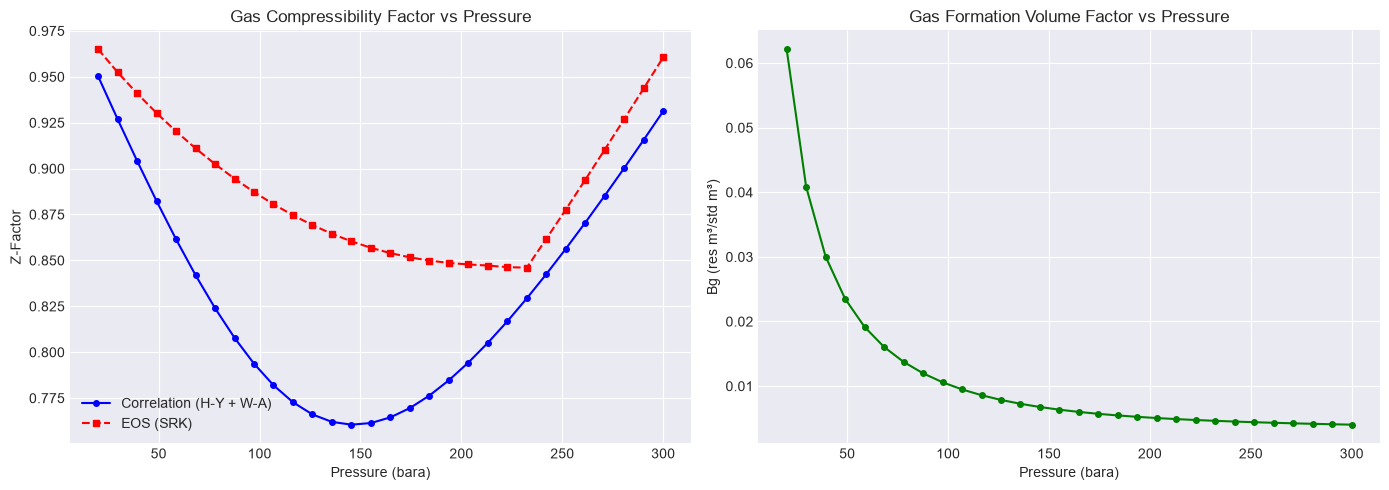

In [4]:
# Pressure sweep from 300 bara down to 20 bara
pressures = np.linspace(20.0, 300.0, 30)
z_corr_list = []
z_eos_list = []
bg_corr_list = []

for p in pressures:
    # Correlation-based Z and Bg
    z_val = float(ZFactorCorrelations.zFactorSourGas(float(p), T_res_K, gammaG, yH2S, yCO2))
    bg_val = float(ZFactorCorrelations.gasFVFFromZ(float(p), T_res_K, gammaG))
    z_corr_list.append(z_val)
    bg_corr_list.append(bg_val)
    
    # EOS-based Z
    test_fluid = reservoir_fluid.clone()
    test_fluid.setPressure(float(p), "bara")
    test_ops = ThermodynamicOperations(test_fluid)
    test_ops.TPflash()
    test_fluid.initProperties()
    z_eos_list.append(float(test_fluid.getPhase(0).getZ()))

# ---- Plot Z-factor vs Pressure ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pressures, z_corr_list, 'b-o', ms=4, label='Correlation (H-Y + W-A)')
axes[0].plot(pressures, z_eos_list, 'r--s', ms=4, label='EOS (SRK)')
axes[0].set_xlabel('Pressure (bara)')
axes[0].set_ylabel('Z-Factor')
axes[0].set_title('Gas Compressibility Factor vs Pressure')
axes[0].legend()
axes[0].grid(True)

# ---- Plot Bg vs Pressure ----
axes[1].plot(pressures, bg_corr_list, 'g-o', ms=4)
axes[1].set_xlabel('Pressure (bara)')
axes[1].set_ylabel('Bg (res m³/std m³)')
axes[1].set_title('Gas Formation Volume Factor vs Pressure')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Real Gas Pseudopressure for Well Deliverability

The real gas pseudopressure $m(P)$ linearizes the gas flow equation. We compute it both from correlations and from the rigorous EOS approach, then plot $m(P)$ vs $P$.

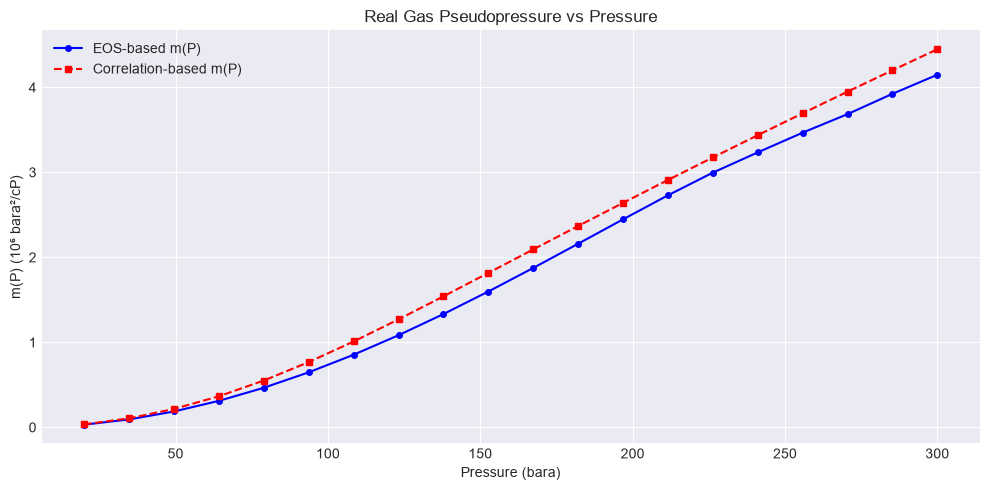


m(P_reservoir) = 4.15e+06 bara²/cP
This pseudopressure value is used for gas well deliverability analysis (IPR).


In [5]:
# ---- EOS-based pseudopressure ----
pseudoP_calc = GasPseudoPressure(reservoir_fluid)
P_ref = 1.01325  # Reference pressure (bara, atmospheric)

# Compute m(P) at several pressures using EOS
p_profile_bara = np.linspace(20.0, 300.0, 20)
mP_eos = []
mP_corr = []

for p in p_profile_bara:
    # EOS approach
    mp_val = float(pseudoP_calc.calculate(float(p), P_ref))
    mP_eos.append(mp_val)
    
    # Correlation approach (using gas gravity and molecular weight)
    mp_corr_val = float(GasPseudoPressure.calculateFromCorrelation(
        float(p), P_ref, T_res_K, gammaG, molar_mass))
    mP_corr.append(mp_corr_val)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p_profile_bara, np.array(mP_eos) / 1e6, 'b-o', ms=4, label='EOS-based m(P)')
ax.plot(p_profile_bara, np.array(mP_corr) / 1e6, 'r--s', ms=4, label='Correlation-based m(P)')
ax.set_xlabel('Pressure (bara)')
ax.set_ylabel('m(P) (10⁶ bara²/cP)')
ax.set_title('Real Gas Pseudopressure vs Pressure')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# ---- IPR deliverability ----
# Simplified back-pressure equation: q = C * [m(Pres) - m(Pwf)]^n
# For this example: n = 1 (laminar), C determined from a test rate
mP_res = float(pseudoP_calc.calculate(float(P_res_bara), P_ref))
print(f"\nm(P_reservoir) = {mP_res:.2e} bara²/cP")
print("This pseudopressure value is used for gas well deliverability analysis (IPR).")

## 6. Water/Brine Properties for Produced Water Handling

As the reservoir depletes and water cut increases, understanding produced water properties is critical for separator sizing, corrosion management, and hydrate inhibitor design. We use the `WaterPropertyCorrelations` module.

In [6]:
# ---- Water properties at reservoir conditions ----
salinity_ppm = 35000.0  # Formation water salinity (ppm NaCl equivalent)
salinity_wt = salinity_ppm / 1e6  # Weight fraction for density calc

print("=== Water / Brine Properties at Reservoir Conditions ===")
print(f"Conditions: {T_res_C:.0f} °C ({T_res_K:.1f} K), {P_res_bara:.0f} bara, {salinity_ppm:.0f} ppm\n")

# Formation volume factor
Bw_mccain = float(WaterPropertyCorrelations.waterFVFMcCain(T_res_K, P_res_bara))
Bw_osif = float(WaterPropertyCorrelations.waterFVFOsif(T_res_K, P_res_bara, salinity_ppm))
print(f"Water FVF (McCain):  {Bw_mccain:.4f} res bbl/STB")
print(f"Water FVF (Osif):    {Bw_osif:.4f} res bbl/STB")

# Viscosity
mu_dead = float(WaterPropertyCorrelations.deadWaterViscosityMcCain(T_res_K, salinity_ppm))
mu_live = float(WaterPropertyCorrelations.waterViscosityMcCain(T_res_K, P_res_bara, salinity_ppm))
print(f"Dead water viscosity: {mu_dead:.3f} cP")
print(f"Live water viscosity: {mu_live:.3f} cP")

# Compressibility
cw = float(WaterPropertyCorrelations.waterCompressibilityMcCain(T_res_K, P_res_bara, salinity_ppm))
print(f"Water compressibility: {cw:.2e} 1/bara")

# Density
rho_brine = float(WaterPropertyCorrelations.brineDensityBatzleWang(T_res_K, P_res_bara, salinity_wt))
rho_water = float(WaterPropertyCorrelations.waterDensity(T_res_K, P_res_bara))
print(f"Pure water density:  {rho_water:.1f} kg/m3")
print(f"Brine density:       {rho_brine:.1f} kg/m3")

# Solution gas-water ratio
Rsw = float(WaterPropertyCorrelations.solutionGasWaterRatioCulberson(T_res_K, P_res_bara, salinity_ppm))
print(f"Solution GWR (Rsw):  {Rsw:.4f} Sm3/Sm3")

# Surface tension
sigma = float(WaterPropertyCorrelations.waterGasSurfaceTension(T_res_K, P_res_bara))
print(f"Water-gas IFT:       {sigma:.1f} dyne/cm")

# ---- Comprehensive summary ----
print("\n--- Full Summary (waterPropertiesSummary) ---")
summary = WaterPropertyCorrelations.waterPropertiesSummary(T_res_K, P_res_bara, salinity_ppm)
for key in summary.keySet():
    print(f"  {key}: {float(summary.get(key)):.6g}")

=== Water / Brine Properties at Reservoir Conditions ===
Conditions: 100 °C (373.1 K), 300 bara, 35000 ppm

Water FVF (McCain):  1.0343 res bbl/STB
Water FVF (Osif):    0.9987 res bbl/STB
Dead water viscosity: 0.322 cP
Live water viscosity: 0.397 cP
Water compressibility: 3.77e-05 1/bara
Pure water density:  973.4 kg/m3
Brine density:       997.2 kg/m3
Solution GWR (Rsw):  3.7831 Sm3/Sm3
Water-gas IFT:       32.6 dyne/cm

--- Full Summary (waterPropertiesSummary) ---
  temperature_K: 373.15
  pressure_bara: 300
  salinity_ppm: 35000
  Bw_McCain_resBblPerSTB: 1.03435
  Bw_Osif_resBblPerSTB: 0.998695
  muW_dead_cP: 0.321698
  muW_cP: 0.396826
  cw_invBara: 3.77156e-05
  rhoW_kgPerM3: 973.35
  Rsw_Sm3PerSm3: 3.78313
  sigma_wg_dynePerCm: 32.5987


## 7. Pipeline Transport Simulation — Subsea Tieback

We model a 50 km subsea pipeline from the wellhead to the host platform using NeqSim's `PipeBeggsAndBrills` multiphase flow model. This gives us inlet/outlet pressures, temperatures, flow regime, and liquid holdup — key inputs for flow assurance.

In [9]:
# ---- Create wellhead stream at flowing conditions ----
# Wellhead conditions after choke: 150 bara, 80 °C
P_wellhead = 150.0  # bara
T_wellhead_C = 80.0
flow_rate_kg_hr = 150000.0  # ~150 tonnes/hr

wellhead_fluid = reservoir_fluid.clone()
wellhead_fluid.setPressure(P_wellhead, "bara")
wellhead_fluid.setTemperature(T_wellhead_C, "C")

wellhead_stream = Stream("Wellhead", wellhead_fluid)
wellhead_stream.setFlowRate(flow_rate_kg_hr, "kg/hr")
wellhead_stream.run()

print(f"Wellhead: {T_wellhead_C:.0f} °C, {P_wellhead:.0f} bara, {flow_rate_kg_hr:.0f} kg/hr")

# ---- Build subsea pipeline using Beggs & Brill ----
pipeline = PipeBeggsAndBrills('pipe1', wellhead_stream)
pipeline.setLength(50000.0)        # 50 km
pipeline.setDiameter(0.3048)       # 12-inch (0.3048 m)
pipeline.setElevation(0.0)         # Horizontal (subsea)
pipeline.setPipeWallRoughness(4.6e-5)  # Smooth steel
pipeline.setNumberOfIncrements(50)
pipeline.setConstantSurfaceTemperature(277.15)   # 4 °C seabed temperature

# Run pipeline flow simulation
pipeline.run()

# ---- Extract results ----
outlet_stream = pipeline.getOutletStream()
P_arrival = float(outlet_stream.getPressure("bara"))
T_arrival_K = float(outlet_stream.getTemperature())
T_arrival_C = T_arrival_K - 273.15
flow_regime = str(pipeline.getFlowRegime())

print(f"\n=== Pipeline Results (50 km subsea) ===")
print(f"Inlet:      {T_wellhead_C:.1f} °C,  {P_wellhead:.1f} bara")
print(f"Outlet:     {T_arrival_C:.1f} °C,  {P_arrival:.1f} bara")
print(f"ΔP:         {P_wellhead - P_arrival:.1f} bar")
print(f"ΔT:         {T_wellhead_C - T_arrival_C:.1f} °C")
print(f"Flow regime: {flow_regime}")

Wellhead: 80 °C, 150 bara, 150000 kg/hr

=== Pipeline Results (50 km subsea) ===
Inlet:      80.0 °C,  150.0 bara
Outlet:     3.9 °C,  133.9 bara
ΔP:         16.1 bar
ΔT:         76.1 °C
Flow regime: INTERMITTENT


## 8. Hydrate Formation Temperature — Flow Assurance Check

We use NeqSim's thermodynamic operations to calculate the hydrate dissociation temperature at the pipeline operating pressure. If the pipeline outlet temperature falls below the hydrate curve, we have a hydrate risk and need inhibition.

Hydrate T at ~arrival pressure: 22.7 °C
Pipeline arrival T:             3.9 °C
Subcooling margin:              18.7 °C
⚠️  Hydrate risk — arrival temperature is below hydrate curve!


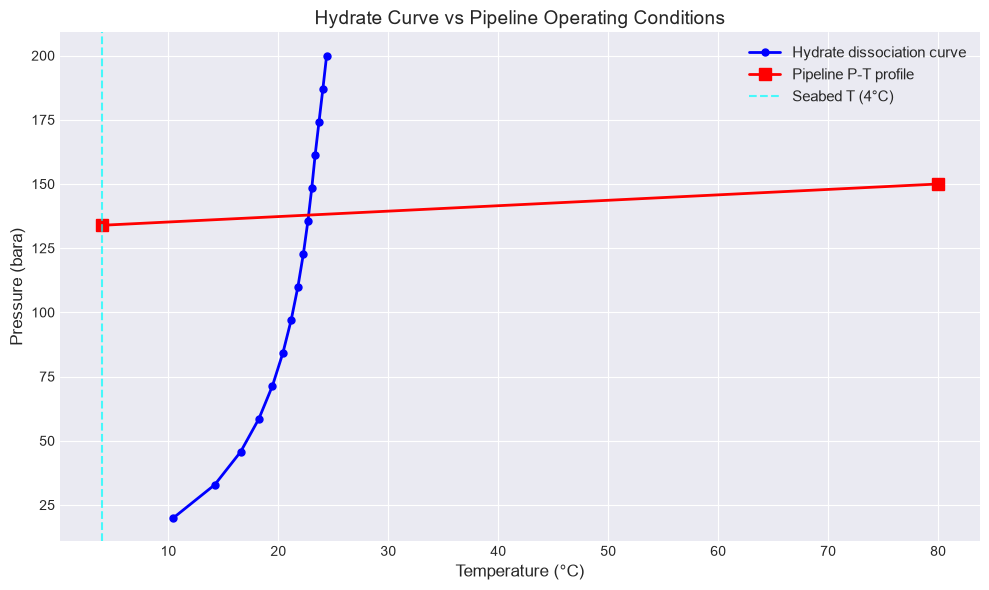

In [12]:
# ---- Hydrate dissociation curve ----
# Hydrate calculations require the CPA EOS (water/MEG association) with the
# hydrate phase enabled. We build a dedicated CPA fluid mirroring the gas
# composition plus free water, and use hydrateFormationTemperature().

# Gas-forming composition (mole fractions) reused for every hydrate fluid
gas_components = [
    ("nitrogen", 0.005), ("CO2", 0.025), ("H2S", 0.001),
    ("methane", 0.700), ("ethane", 0.085), ("propane", 0.045),
    ("i-butane", 0.010), ("n-butane", 0.020), ("i-pentane", 0.008),
    ("n-pentane", 0.012), ("n-hexane", 0.015), ("n-heptane", 0.020),
]


def build_hydrate_fluid(pressure_bara, meg_wt=0.0, water_moles=2.0):
    """Build a CPA fluid (gas + water + optional MEG) for hydrate calculations."""
    f = SystemSrkCPAstatoil(273.15 + 10.0, float(pressure_bara))
    for name, frac in gas_components:
        f.addComponent(name, frac)
    f.addComponent("water", float(water_moles))
    if meg_wt > 0:
        # Convert MEG wt% (of the aqueous phase) to a mole amount
        # MEG MW = 62.07 g/mol, water MW = 18.015 g/mol
        meg_mole_frac = (meg_wt / 62.07) / (meg_wt / 62.07 + (1 - meg_wt) / 18.015)
        meg_moles = water_moles * meg_mole_frac / (1 - meg_mole_frac)
        f.addComponent("MEG", float(meg_moles))
    f.setMixingRule(10)            # CPA mixing rule
    f.setMultiPhaseCheck(True)
    f.setHydrateCheck(True)
    return f


# Calculate hydrate dissociation temperature over a range of pressures
hydrate_pressures = np.linspace(20.0, 200.0, 15)
hydrate_temps_C = []

for p in hydrate_pressures:
    hyd_fluid = build_hydrate_fluid(p)
    hyd_ops = ThermodynamicOperations(hyd_fluid)
    try:
        hyd_ops.hydrateFormationTemperature()
        T_hyd = float(hyd_fluid.getTemperature()) - 273.15
        hydrate_temps_C.append(T_hyd)
    except Exception:
        hydrate_temps_C.append(float('nan'))

# ---- Plot hydrate curve vs pipeline operating conditions ----
fig, ax = plt.subplots(figsize=(10, 6))

# Hydrate curve
ax.plot(hydrate_temps_C, hydrate_pressures, 'b-o', ms=5, lw=2, label='Hydrate dissociation curve')

# Pipeline operating envelope (approximate linear from inlet to outlet)
pipe_T = [T_wellhead_C, T_arrival_C]
pipe_P = [P_wellhead, P_arrival]
ax.plot(pipe_T, pipe_P, 'r-s', ms=8, lw=2, label='Pipeline P-T profile')

# Seabed temperature reference
ax.axvline(x=4.0, color='cyan', linestyle='--', alpha=0.7, label='Seabed T (4°C)')

# Add labels
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Pressure (bara)', fontsize=12)
ax.set_title('Hydrate Curve vs Pipeline Operating Conditions', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True)

# Check subcooling at pipeline arrival pressure
valid_hyd = [(t, p) for t, p in zip(hydrate_temps_C, hydrate_pressures)
             if not np.isnan(t) and p <= P_arrival + 10]
if valid_hyd:
    T_hyd_at_arrival = max(t for t, p in valid_hyd if p <= P_arrival + 5)
    subcooling = T_hyd_at_arrival - T_arrival_C
    print(f"Hydrate T at ~arrival pressure: {T_hyd_at_arrival:.1f} °C")
    print(f"Pipeline arrival T:             {T_arrival_C:.1f} °C")
    print(f"Subcooling margin:              {subcooling:.1f} °C")
    if subcooling > 0:
        print("⚠️  Hydrate risk — arrival temperature is below hydrate curve!")
    else:
        print("✅ No hydrate risk at normal operating conditions.")
else:
    print("Hydrate curve calculation did not converge for the tested range.")

plt.tight_layout()
plt.show()

## 9. MEG Hydrate Inhibitor Injection Calculations

If hydrates are a risk, we inject MEG (monoethylene glycol) to shift the hydrate curve. We recalculate the hydrate temperature at several MEG concentrations to find the minimum dose needed.

In [13]:
# ---- MEG inhibition study ----
# Test MEG concentrations: 0, 20, 30, 40 wt% in aqueous phase
# Reuses the CPA-based build_hydrate_fluid() helper defined above.
meg_concentrations = [0.0, 0.20, 0.30, 0.40]
test_pressure = P_arrival  # Test at pipeline arrival pressure

print(f"=== Hydrate Inhibition Study at {test_pressure:.0f} bara ===\n")
print(f"{'MEG wt%':>8}  {'Hydrate T (°C)':>15}  {'Subcooling (°C)':>16}")
print("-" * 44)

hydrate_results = {}
for meg_wt in meg_concentrations:
    inh_fluid = build_hydrate_fluid(test_pressure, meg_wt=meg_wt)
    inh_ops = ThermodynamicOperations(inh_fluid)
    try:
        inh_ops.hydrateFormationTemperature()
        T_hyd = float(inh_fluid.getTemperature()) - 273.15
        subcool = T_hyd - T_arrival_C
        print(f"{meg_wt*100:>7.0f}%  {T_hyd:>14.1f}  {subcool:>15.1f}")
        hydrate_results[meg_wt] = T_hyd
    except Exception:
        print(f"{meg_wt*100:>7.0f}%  {'Error':>14}  {'N/A':>15}")

# Determine required MEG concentration
print(f"\nPipeline arrival temperature: {T_arrival_C:.1f} °C")
for meg_wt, T_hyd in hydrate_results.items():
    if T_hyd < T_arrival_C:
        print(f"✅ {meg_wt*100:.0f} wt% MEG shifts hydrate curve below pipeline T")

        # Calculate MEG injection rate
        water_rate_m3hr = 5.0  # Assumed produced water rate (m3/hr)
        meg_density = 1110.0   # kg/m3
        meg_rate_kg_hr = water_rate_m3hr * 1000 * meg_wt / (1 - meg_wt)
        meg_rate_m3_hr = meg_rate_kg_hr / meg_density
        print(f"   Required MEG rate: {meg_rate_kg_hr:.0f} kg/hr ({meg_rate_m3_hr:.2f} m3/hr)")
        print(f"   at {water_rate_m3hr:.1f} m3/hr produced water")
        break

=== Hydrate Inhibition Study at 134 bara ===

 MEG wt%   Hydrate T (°C)   Subcooling (°C)
--------------------------------------------
      0%            22.6             18.7
     20%            16.8             12.8
     30%            12.5              8.6
     40%             7.1              3.2

Pipeline arrival temperature: 3.9 °C


## 10. Inlet Separation — Slug Catcher and Two-Stage Separation

The pipeline outlet feeds into a topside process train. We model:
1. **Inlet separator** (three-phase) at pipeline arrival conditions
2. **Pressure reduction valve** to reduce to LP separator pressure
3. **LP separator** for further gas/liquid separation

In [14]:
# ---- Build inlet separation process ----
process = ProcessSystem()

# Use pipeline outlet as feed
inlet_fluid = reservoir_fluid.clone()
inlet_fluid.setPressure(P_arrival, "bara")
inlet_fluid.setTemperature(T_arrival_C, "C")
# Add some water to simulate wet production
inlet_fluid.addComponent("water", 0.05)
inlet_fluid.createDatabase(True)
inlet_fluid.setMixingRule("classic")
inlet_fluid.setMultiPhaseCheck(True)

feed_stream = Stream("Pipeline Arrival", inlet_fluid)
feed_stream.setFlowRate(flow_rate_kg_hr, "kg/hr")
process.add(feed_stream)

# HP inlet separator (three-phase)
hp_separator = ThreePhaseSeparator("HP Separator", feed_stream)
process.add(hp_separator)

# Pressure reduction valve on HP liquid
hp_liquid = hp_separator.getOilOutStream()
jt_valve = ThrottlingValve("JT Valve", hp_liquid)
jt_valve.setOutletPressure(30.0)  # 30 bara LP separator
process.add(jt_valve)

# LP separator
lp_separator = Separator("LP Separator", jt_valve.getOutletStream())
process.add(lp_separator)

# Run the separation process
process.run()

# ---- Report separation results ----
hp_gas = hp_separator.getGasOutStream()
hp_oil = hp_separator.getOilOutStream()
hp_water = hp_separator.getWaterOutStream()
lp_gas = lp_separator.getGasOutStream()
lp_liquid = lp_separator.getLiquidOutStream()

print("=== Inlet Separation Results ===\n")
print(f"{'Stream':25s} {'T (°C)':>8} {'P (bara)':>9} {'Flow (kg/hr)':>13}")
print("-" * 58)

for name, s in [("Feed", feed_stream), 
                ("HP Gas", hp_gas), 
                ("HP Oil", hp_oil),
                ("HP Water", hp_water),
                ("LP Gas (flash gas)", lp_gas),
                ("LP Liquid (stab. oil)", lp_liquid)]:
    T = float(s.getTemperature()) - 273.15
    P = float(s.getPressure("bara"))
    F = float(s.getFlowRate("kg/hr"))
    print(f"{name:25s} {T:>7.1f} {P:>9.1f} {F:>13.0f}")

=== Inlet Separation Results ===

Stream                      T (°C)  P (bara)  Flow (kg/hr)
----------------------------------------------------------
Feed                          3.9     133.9        150000
HP Gas                        3.9     133.9         49339
HP Oil                        3.9     133.9         96403
HP Water                      3.9     133.9          4258
LP Gas (flash gas)          -16.7      30.0         22269
LP Liquid (stab. oil)       -16.7      30.0         74134


## 11. Gas Compression and Export

The HP separator gas already arrives near export pressure, so the LP separator flash gas is recompressed in two stages with intercooling to reach export pipeline pressure (200 bara). We calculate compressor power, discharge temperatures, and verify the gas quality.

In [16]:
# ---- Gas compression train (LP flash-gas recompression) ----
# The HP separator gas already arrives near export pressure, so the two-stage
# train with intercooling recompresses the LP flash gas (30 bara) up to the
# export pipeline pressure (200 bara).
export_process = ProcessSystem()

# Feed from LP separator flash gas
gas_feed = Stream("LP Flash Gas Feed", lp_gas.getFluid().clone())
gas_feed.setFlowRate(float(lp_gas.getFlowRate("kg/hr")), "kg/hr")
gas_feed.setPressure(float(lp_gas.getPressure("bara")), "bara")
gas_feed.setTemperature(float(lp_gas.getTemperature()) - 273.15, "C")
export_process.add(gas_feed)

# Stage 1: Compress to intermediate pressure (~80 bara)
comp1 = Compressor("Compressor Stage 1", gas_feed)
comp1.setOutletPressure(80.0)
comp1.setPolytropicEfficiency(0.78)
comp1.setUsePolytropicCalc(True)
export_process.add(comp1)

# Intercooler: cool back to 40 °C
cooler1 = Cooler("Intercooler 1", comp1.getOutletStream())
cooler1.setOutTemperature(273.15 + 40.0)
export_process.add(cooler1)

# Stage 2: Compress to export pressure (200 bara)
comp2 = Compressor("Compressor Stage 2", cooler1.getOutletStream())
comp2.setOutletPressure(200.0)
comp2.setPolytropicEfficiency(0.78)
comp2.setUsePolytropicCalc(True)
export_process.add(comp2)

# Aftercooler: cool to 40 °C before export
cooler2 = Cooler("Aftercooler", comp2.getOutletStream())
cooler2.setOutTemperature(273.15 + 40.0)
export_process.add(cooler2)

# Run compression train
export_process.run()

# ---- Results ----
print("=== Gas Compression Train (LP flash-gas recompression) ===\n")
print(f"{'Stage':20s} {'T_in(°C)':>9} {'T_out(°C)':>10} {'P_out(bara)':>12} {'Power(kW)':>10}")
print("-" * 65)

for name, comp in [("Stage 1", comp1), ("Stage 2", comp2)]:
    T_in = float(comp.getInletStream().getTemperature()) - 273.15
    T_out = float(comp.getOutletStream().getTemperature()) - 273.15
    P_out = float(comp.getOutletStream().getPressure("bara"))
    power = float(comp.getPower("kW"))
    print(f"{name:20s} {T_in:>8.1f} {T_out:>10.1f} {P_out:>12.1f} {power:>10.0f}")

total_power = float(comp1.getPower("kW")) + float(comp2.getPower("kW"))
print(f"\nTotal compression power: {total_power:.0f} kW ({total_power/1000:.1f} MW)")

# Export gas conditions
export_gas = cooler2.getOutletStream()
T_export = float(export_gas.getTemperature()) - 273.15
P_export = float(export_gas.getPressure("bara"))
export_flow = float(export_gas.getFlowRate("kg/hr"))
print(f"\nRecompressed export gas: {T_export:.1f} °C, {P_export:.1f} bara, {export_flow:.0f} kg/hr")

=== Gas Compression Train (LP flash-gas recompression) ===

Stage                 T_in(°C)  T_out(°C)  P_out(bara)  Power(kW)
-----------------------------------------------------------------
Stage 1                 -16.7       67.4         80.0        911
Stage 2                  40.0      126.3        200.0       1047

Total compression power: 1958 kW (2.0 MW)

Recompressed export gas: 40.0 °C, 200.0 bara, 22269 kg/hr


## 12. Oil Stabilization and Export Crude

The LP separator liquid is flashed to near-atmospheric pressure to remove remaining volatiles, producing stabilized crude oil for export.

In [ ]:
# ---- Oil stabilization (heat then flash to ~2 bara) ----
stab_process = ProcessSystem()

oil_feed = Stream("LP oil feed", lp_liquid.getFluid().clone())
oil_feed.setFlowRate(float(lp_liquid.getFlowRate("kg/hr")), "kg/hr")
oil_feed.setPressure(float(lp_liquid.getPressure("bara")), "bara")
oil_feed.setTemperature(float(lp_liquid.getTemperature()) - 273.15, "C")
stab_process.add(oil_feed)

# Stabilizer feed heater: warm the cold LP oil to drive off light ends
stab_heater = Heater("Stabilizer Heater", oil_feed)
stab_heater.setOutTemperature(273.15 + 50.0)  # 50 °C stabilization temperature
stab_process.add(stab_heater)

# Stabilizer valve
stab_valve = ThrottlingValve("Stabilizer Valve", stab_heater.getOutletStream())
stab_valve.setOutletPressure(2.0)  # ~atmospheric
stab_process.add(stab_valve)

# Stabilizer separator
stab_sep = Separator("Stabilizer", stab_valve.getOutletStream())
stab_process.add(stab_sep)

stab_process.run()

# ---- Report stabilized crude properties ----
stab_oil = stab_sep.getLiquidOutStream()
stab_gas = stab_sep.getGasOutStream()

stab_oil_fluid = stab_oil.getFluid()
stab_oil_T = float(stab_oil.getTemperature()) - 273.15
stab_oil_P = float(stab_oil.getPressure("bara"))
stab_oil_flow = float(stab_oil.getFlowRate("kg/hr"))
stab_oil_density = float(stab_oil_fluid.getDensity("kg/m3"))

# API gravity from density (at standard-ish conditions)
api_gravity = 141.5 / (stab_oil_density / 999.0) - 131.5

print("=== Stabilized Crude Oil ===\n")
print(f"Temperature:    {stab_oil_T:.1f} °C")
print(f"Pressure:       {stab_oil_P:.1f} bara")
print(f"Flow rate:      {stab_oil_flow:.0f} kg/hr")
print(f"Density:        {stab_oil_density:.1f} kg/m3")
print(f"API gravity:    {api_gravity:.1f} °API")

stab_gas_flow = float(stab_gas.getFlowRate("kg/hr"))
print(f"\nStabilizer flash gas: {stab_gas_flow:.0f} kg/hr (route to fuel gas or compression)")

=== Stabilized Crude Oil ===

Temperature:    -35.1 °C
Pressure:       2.0 bara
Flow rate:      66012 kg/hr
Density:        718.2 kg/m3
API gravity:    65.3 °API

Stabilizer flash gas: 8122 kg/hr (route to fuel gas or compression)


## 13. Production Decline Forecast with Decline Curve Analysis

We use the `DeclineCurveAnalysis` module to forecast production over the field life. Starting from an initial gas rate of 25 MMSm3/d, we model hyperbolic decline (b=0.5) and exponential decline to estimate EUR and production profiles.

In [ ]:
# ---- Decline Curve Analysis Parameters ----
qi = 25.0       # Initial gas rate (MMSm3/d)
di = 0.0008     # Initial nominal decline (1/day) ~ 25% effective annual
b_hyp = 0.5     # Hyperbolic exponent
q_limit = 2.0   # Economic limit (MMSm3/d)

# ---- Compare Exponential vs Hyperbolic Decline ----
print("=== Decline Curve Analysis ===\n")

# DCA summary for hyperbolic
summary = DeclineCurveAnalysis.summary(qi, di, b_hyp, q_limit)
print("Hyperbolic decline (b = 0.5):")
for key in summary.keySet():
    print(f"  {str(key):35s}: {float(summary.get(key)):.4g}")

# Effective annual decline rate
d_eff = float(DeclineCurveAnalysis.nominalToEffectiveAnnual(di))
print(f"\nEffective annual decline: {d_eff*100:.1f}%")

# ---- Generate forecast profiles ----
years = 20
forecast_hyp = DeclineCurveAnalysis.forecast(qi, di, b_hyp, 0, years * 365, 30)
forecast_exp = DeclineCurveAnalysis.forecast(qi, di, 0.0, 0, years * 365, 30)

# Convert Java arrays to numpy
times_days = np.array([float(forecast_hyp[0][i]) for i in range(len(forecast_hyp[0]))])
rates_hyp = np.array([float(forecast_hyp[1][i]) for i in range(len(forecast_hyp[1]))])
cum_hyp = np.array([float(forecast_hyp[2][i]) for i in range(len(forecast_hyp[2]))])
rates_exp = np.array([float(forecast_exp[1][i]) for i in range(len(forecast_exp[1]))])
cum_exp = np.array([float(forecast_exp[2][i]) for i in range(len(forecast_exp[2]))])

times_years = times_days / 365.25

# ---- Plot production profiles ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rate vs time
axes[0].plot(times_years, rates_hyp, 'b-', lw=2, label=f'Hyperbolic (b={b_hyp})')
axes[0].plot(times_years, rates_exp, 'r--', lw=2, label='Exponential (b=0)')
axes[0].axhline(y=q_limit, color='gray', linestyle=':', label=f'Economic limit ({q_limit} MMSm3/d)')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Gas Rate (MMSm3/d)')
axes[0].set_title('Production Rate Decline')
axes[0].legend()
axes[0].grid(True)

# Cumulative production
axes[1].plot(times_years, cum_hyp / 1000, 'b-', lw=2, label=f'Hyperbolic (b={b_hyp})')
axes[1].plot(times_years, cum_exp / 1000, 'r--', lw=2, label='Exponential (b=0)')
axes[1].set_xlabel('Time (years)')
axes[1].set_ylabel('Cumulative Production (10³ MMSm3·day)')
axes[1].set_title('Cumulative Gas Production')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# EUR comparison
eur_hyp = float(DeclineCurveAnalysis.eur(qi, di, b_hyp, q_limit))
eur_exp = float(DeclineCurveAnalysis.eur(qi, di, 0.0, q_limit))
print(f"\nEUR (hyperbolic): {eur_hyp:.0f} MMSm3·days = {eur_hyp/365.25:.0f} MMSm3 equivalent")
print(f"EUR (exponential): {eur_exp:.0f} MMSm3·days = {eur_exp/365.25:.0f} MMSm3 equivalent")

## 14. Integrated Life-of-Field Simulation

We bring everything together: at each time step over the field life, we:
1. Get the gas rate from the decline curve
2. Estimate reservoir pressure from a simplified P/Z material balance
3. Recalculate Z-factor and gas properties at current conditions
4. Run the pipeline pressure drop calculation
5. Check hydrate risk at pipeline arrival conditions
6. Track export gas rate and cumulative production

In [ ]:
# ---- Life-of-field integrated simulation ----
# Material balance: P/Z (current) = P/Z (initial) * (1 - Gp/OGIP)
P_initial = P_res_bara
Z_initial = float(ZFactorCorrelations.zFactorSourGas(P_initial, T_res_K, gammaG, yH2S, yCO2))
OGIP = 50000.0  # Original gas in place (same units as cumulative from DCA, MMSm3·days equivalent)

# Time steps: every 6 months for 15 years
time_steps_days = np.arange(0, 15 * 365 + 1, 182)

# Storage arrays
results = {
    'time_yr': [], 'gas_rate': [], 'cum_prod': [],
    'P_reservoir': [], 'Z_factor': [], 'gas_density': [],
    'P_arrival': [], 'T_arrival_C': [], 'hydrate_margin': []
}

for t in time_steps_days:
    # 1. Gas rate from decline curve
    q = float(DeclineCurveAnalysis.rate(qi, di, b_hyp, float(t)))
    Gp = float(DeclineCurveAnalysis.cumulativeProduction(qi, di, b_hyp, float(t)))
    
    # 2. Reservoir pressure from P/Z material balance
    recovery_fraction = Gp / OGIP if OGIP > 0 else 0
    if recovery_fraction >= 0.95:
        break
    PoverZ_current = (P_initial / Z_initial) * (1.0 - recovery_fraction)
    
    # 3. Solve for P: need Z(P), but Z depends on P -> iterate
    P_res = P_initial * (1.0 - recovery_fraction)  # Initial guess
    for _ in range(10):  # Simple iteration
        Z_cur = float(ZFactorCorrelations.zFactorSourGas(
            float(P_res), T_res_K, gammaG, yH2S, yCO2))
        P_res = PoverZ_current * Z_cur
        if P_res < 10:
            P_res = 10.0
            break
    
    Z_cur = float(ZFactorCorrelations.zFactorSourGas(
        float(P_res), T_res_K, gammaG, yH2S, yCO2))
    rho_gas = float(ZFactorCorrelations.gasDensity(
        float(P_res), T_res_K, gammaG, molar_mass))
    
    # 4. Pipeline arrival pressure (simplified: scale DP with flow rate squared)
    # DP proportional to q^2 at reference conditions
    DP_ref = P_wellhead - P_arrival  # From initial simulation
    q_ratio = q / qi
    DP_current = DP_ref * q_ratio * q_ratio
    P_wh_current = min(P_res * 0.85, P_wellhead)  # Simplified wellhead pressure
    P_arrival_current = max(P_wh_current - DP_current, 20.0)
    
    # 5. Arrival temperature (simplified: scales with flow)
    T_arr_C = 4.0 + (T_wellhead_C - 4.0) * min(q_ratio, 1.0)
    
    # Store results
    results['time_yr'].append(t / 365.25)
    results['gas_rate'].append(q)
    results['cum_prod'].append(Gp)
    results['P_reservoir'].append(P_res)
    results['Z_factor'].append(Z_cur)
    results['gas_density'].append(rho_gas)
    results['P_arrival'].append(P_arrival_current)
    results['T_arrival_C'].append(T_arr_C)

# Convert to numpy arrays
for key in results:
    results[key] = np.array(results[key])

print(f"Simulation ran for {results['time_yr'][-1]:.1f} years")
print(f"Final reservoir pressure: {results['P_reservoir'][-1]:.1f} bara")
print(f"Final gas rate: {results['gas_rate'][-1]:.2f} MMSm3/d")
print(f"Total cumulative production: {results['cum_prod'][-1]:.0f} MMSm3·days")

## 15. Life-of-Field Plots — Production Profiles and Facility Constraints

Visualize the integrated results: production rates, reservoir pressure, Z-factor, pipeline conditions, and flow assurance margins over the field life.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Gas production rate
axes[0, 0].plot(results['time_yr'], results['gas_rate'], 'b-', lw=2)
axes[0, 0].axhline(y=q_limit, color='red', linestyle='--', label=f'Economic limit ({q_limit})')
axes[0, 0].set_xlabel('Time (years)')
axes[0, 0].set_ylabel('Gas Rate (MMSm3/d)')
axes[0, 0].set_title('Gas Production Rate')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Cumulative production
axes[0, 1].plot(results['time_yr'], results['cum_prod'] / 1000, 'g-', lw=2)
axes[0, 1].set_xlabel('Time (years)')
axes[0, 1].set_ylabel('Cumulative (10³ MMSm3·d)')
axes[0, 1].set_title('Cumulative Gas Production')
axes[0, 1].grid(True)

# 3. Reservoir pressure
axes[0, 2].plot(results['time_yr'], results['P_reservoir'], 'r-', lw=2)
axes[0, 2].set_xlabel('Time (years)')
axes[0, 2].set_ylabel('P_res (bara)')
axes[0, 2].set_title('Reservoir Pressure Decline')
axes[0, 2].grid(True)

# 4. Z-factor evolution
axes[1, 0].plot(results['time_yr'], results['Z_factor'], 'm-', lw=2)
axes[1, 0].set_xlabel('Time (years)')
axes[1, 0].set_ylabel('Z-Factor')
axes[1, 0].set_title('Gas Z-Factor (at reservoir T)')
axes[1, 0].grid(True)

# 5. Pipeline arrival conditions
ax5 = axes[1, 1]
ax5_twin = ax5.twinx()
ax5.plot(results['time_yr'], results['P_arrival'], 'b-', lw=2, label='P_arrival')
ax5_twin.plot(results['time_yr'], results['T_arrival_C'], 'r--', lw=2, label='T_arrival')
ax5.set_xlabel('Time (years)')
ax5.set_ylabel('Arrival Pressure (bara)', color='blue')
ax5_twin.set_ylabel('Arrival Temperature (°C)', color='red')
ax5.set_title('Pipeline Arrival Conditions')
ax5.grid(True)
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5_twin.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc='best')

# 6. Gas density at reservoir conditions
axes[1, 2].plot(results['time_yr'], results['gas_density'], 'k-', lw=2)
axes[1, 2].set_xlabel('Time (years)')
axes[1, 2].set_ylabel('Gas Density (kg/m3)')
axes[1, 2].set_title('Reservoir Gas Density')
axes[1, 2].grid(True)

plt.suptitle('Integrated Field Life Simulation — Reservoir to Export', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ---- Summary statistics ----
print("=== Field Life Summary ===")
print(f"Field life to economic limit: {float(DeclineCurveAnalysis.timeToRate(qi, di, b_hyp, q_limit))/365.25:.1f} years")
print(f"Initial gas rate:     {qi:.1f} MMSm3/d")
print(f"Final gas rate:       {results['gas_rate'][-1]:.2f} MMSm3/d")
print(f"Initial P_res:        {P_initial:.0f} bara")
print(f"Final P_res:          {results['P_reservoir'][-1]:.0f} bara")
print(f"Compression power (initial): {total_power:.0f} kW ({total_power/1000:.1f} MW)")

## Summary

This notebook demonstrated a complete **reservoir-to-export workflow** using NeqSim, combining:

| Module | What it does | NeqSim Class |
|--------|-------------|--------------|
| **Pseudocritical Properties** | Gas gravity to Tpc/Ppc (Kelvin/bara) | `GasPseudoCriticalProperties` |
| **Z-Factor Correlations** | Hall-Yarborough, DAK, Papay + convenience methods | `ZFactorCorrelations` |
| **Gas Pseudopressure** | Real gas potential m(P) for deliverability | `GasPseudoPressure` |
| **Water Correlations** | Brine FVF, viscosity, density, compressibility | `WaterPropertyCorrelations` |
| **Decline Curve Analysis** | Arps decline, EUR, forecasting | `DeclineCurveAnalysis` |
| **Pipeline Flow** | Beggs & Brill multiphase pressure drop | `PipeBeggsAndBrills` |
| **Hydrate Prediction** | Hydrate equilibrium temperature | `ThermodynamicOperations` |
| **MEG Inhibition** | Hydrate curve shift with inhibitor | NeqSim fluid + MEG component |
| **Process Simulation** | Separation, compression, stabilization | `ProcessSystem` + equipment |

**Key integrations demonstrated:**
- Correlation-based reservoir properties validated against rigorous EOS
- Pipeline P-T profile checked against hydrate formation curve
- MEG inhibitor dosing calculated from thermodynamic hydrate shift
- Two-stage separation with gas compression to export specifications
- Decline curve driving life-of-field facility sizing via P/Z material balance

All reservoir utility classes use **Kelvin** and **bara** as default units, consistent with NeqSim's process simulation.